# Act 5 - Kê đơn hành động cho từng chương trình

**Câu hỏi trung tâm:** Dựa trên hiệu quả tài chính, chất lượng khách hàng và rủi ro tồn kho, chương trình nào nên KEEP, CUT hoặc RESCHEDULE?

Phần cuối chuyển toàn bộ kết quả phân tích thành quyết định cụ thể cho từng chương trình.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"


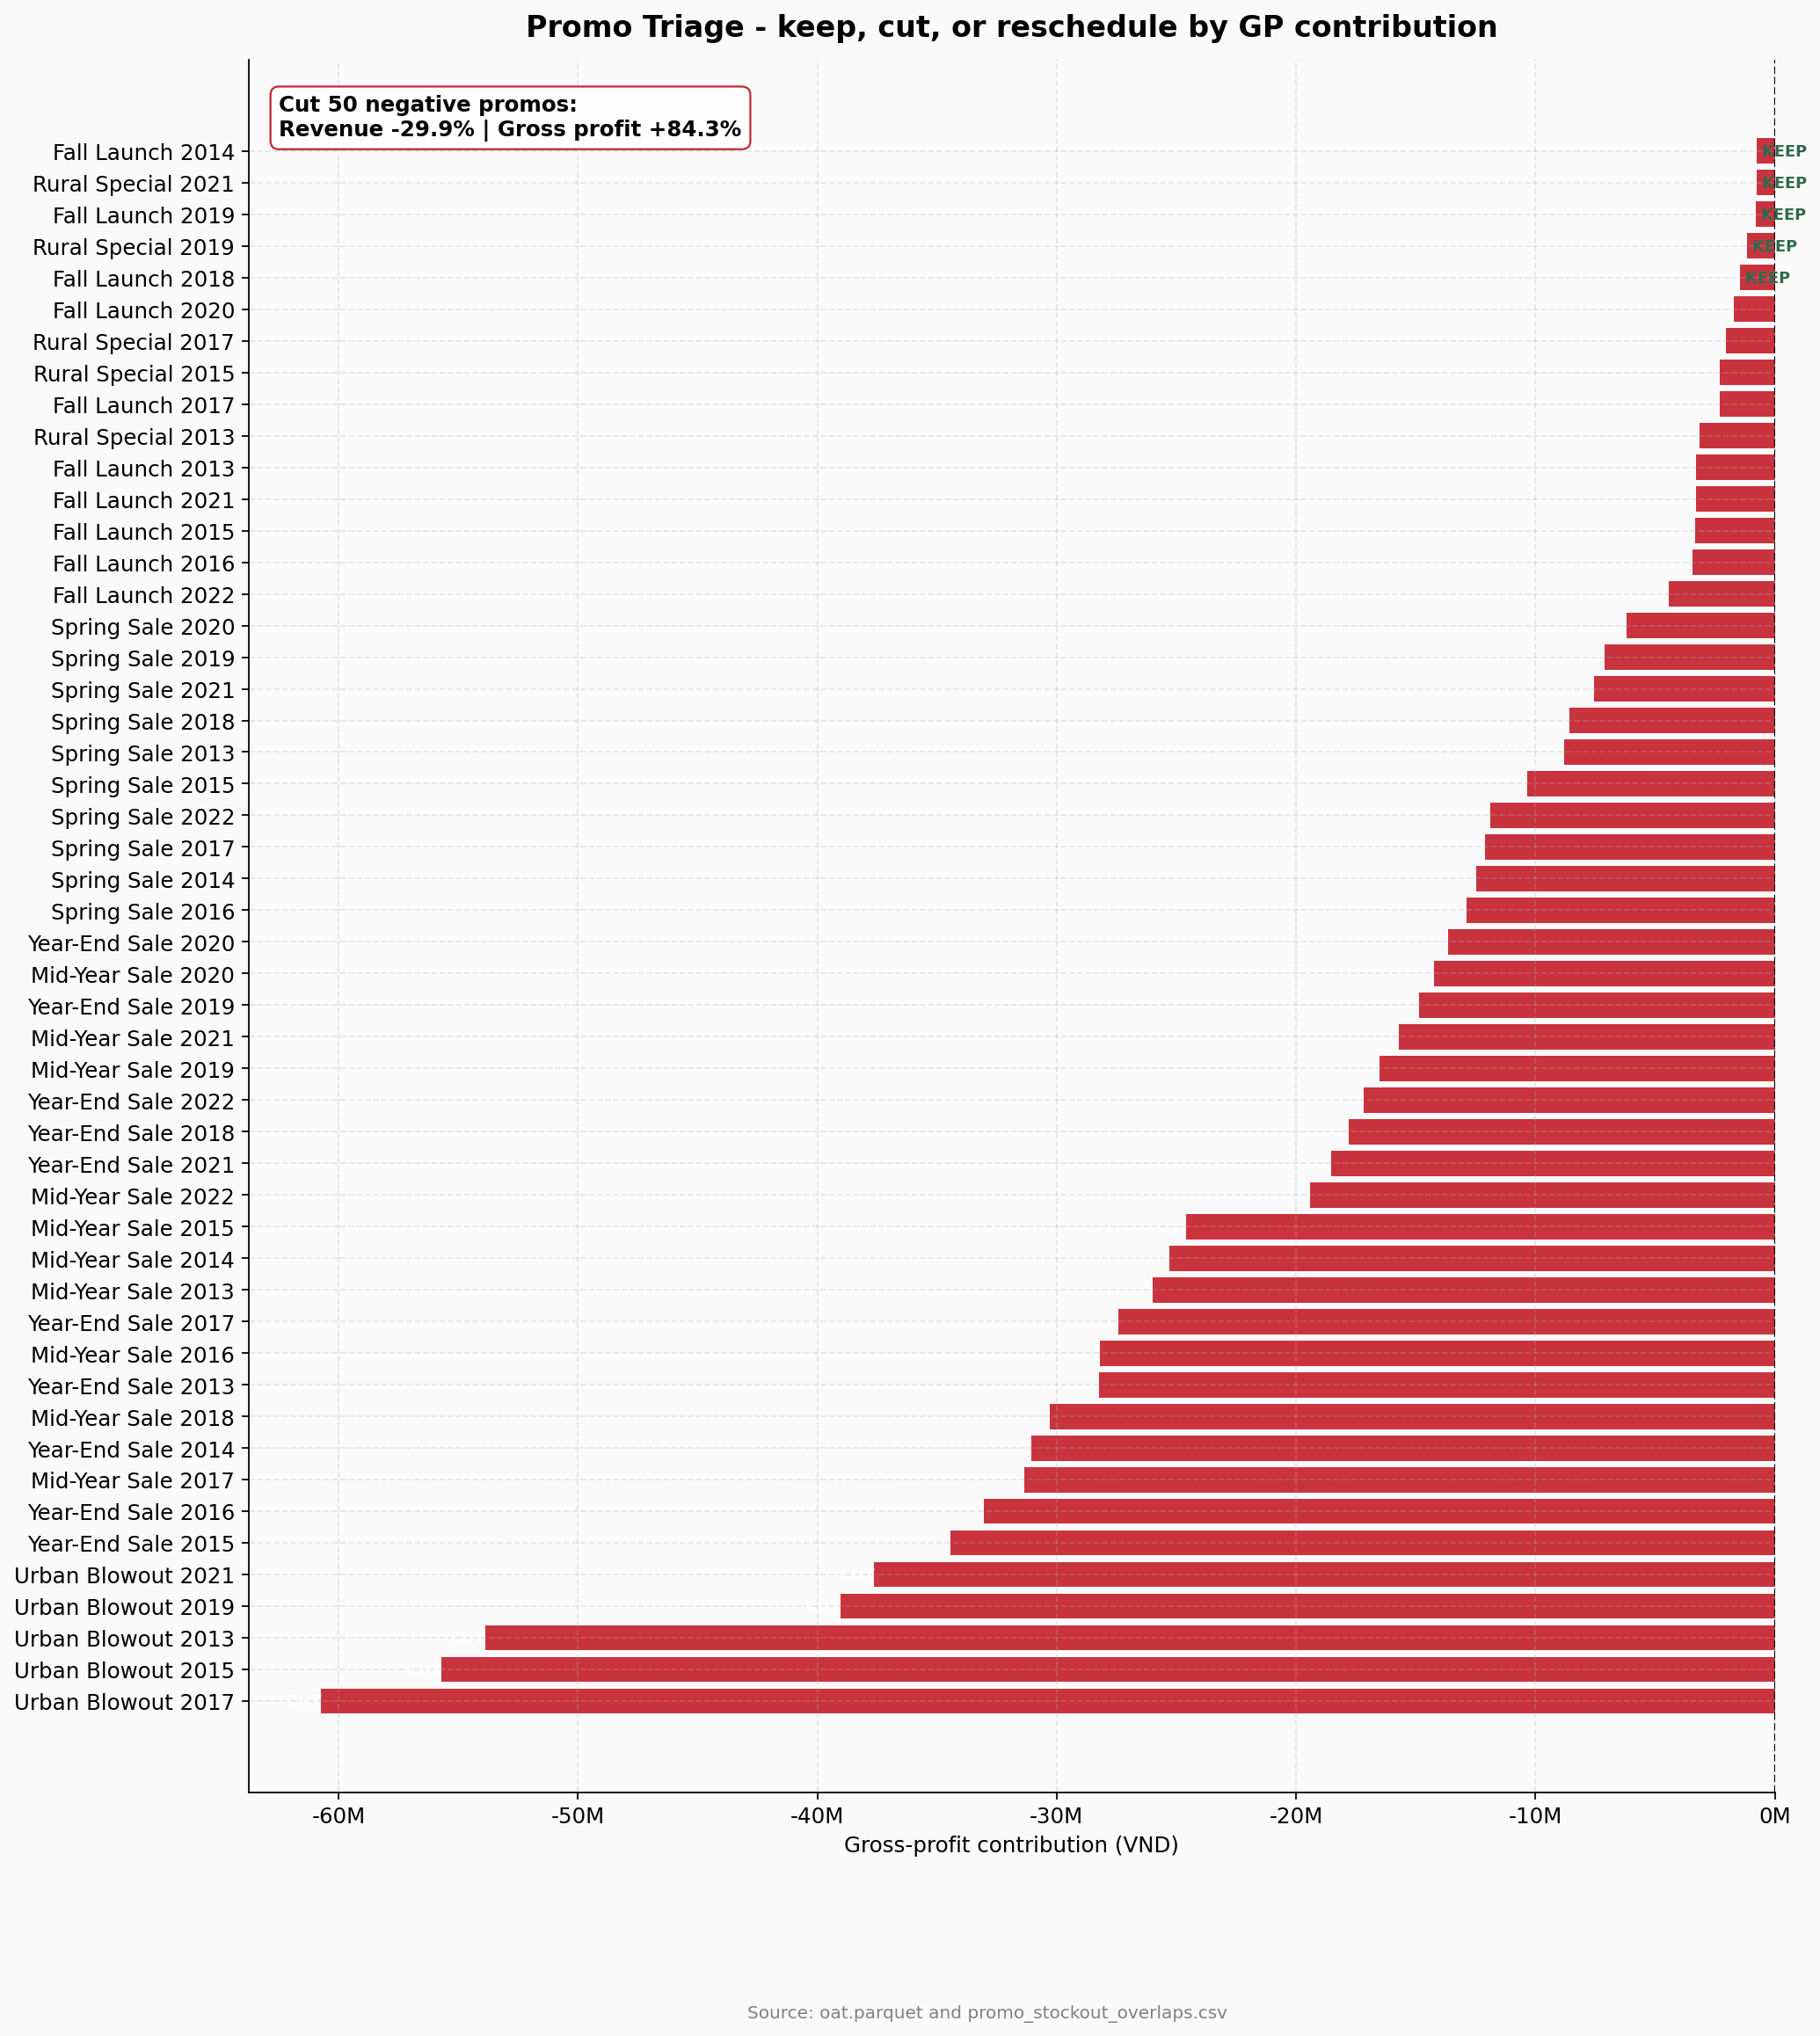

In [2]:
display(Image(str(CHARTS / "chart7_promo_triage.png"), width=950))


In [3]:
triage = pd.read_csv(TABLES / "promo_triage_table.csv")
summary = triage.groupby("verdict").agg(
    count=("promo_id", "count"),
    total_net_contribution=("total_net_contribution", "sum"),
    estimated_annual_impact_vnd=("estimated_annual_impact_vnd", "sum"),
).reset_index()
summary_display = summary.rename(columns={
    "verdict": "quyet_dinh",
    "count": "so_chuong_trinh",
    "total_net_contribution": "tong_dong_gop_loi_nhuan_gop",
    "estimated_annual_impact_vnd": "tac_dong_uoc_tinh_nam_vnd",
})
display(summary_display)
print("Các chương trình CUT ít âm nhất")
cols = ["promo_name", "total_net_contribution", "return_rate", "stockout_overlap"]
display(triage[triage.verdict == "CUT"].nlargest(5, "total_net_contribution")[cols].rename(columns={
    "promo_name": "ten_khuyen_mai",
    "total_net_contribution": "dong_gop_loi_nhuan_gop",
    "return_rate": "ty_le_tra_hang",
    "stockout_overlap": "chong_lan_thieu_hang",
}))
print("Các chương trình CUT âm nặng nhất")
display(triage[triage.verdict == "CUT"].nsmallest(5, "total_net_contribution")[cols].rename(columns={
    "promo_name": "ten_khuyen_mai",
    "total_net_contribution": "dong_gop_loi_nhuan_gop",
    "return_rate": "ty_le_tra_hang",
    "stockout_overlap": "chong_lan_thieu_hang",
}))


,quyet_dinh,so_chuong_trinh,tong_dong_gop_loi_nhuan_gop,tac_dong_uoc_tinh_nam_vnd
0,CUT,50,-8.468795e+08,8.468795e+08


Các chương trình CUT ít âm nhất


,ten_khuyen_mai,dong_gop_loi_nhuan_gop,ty_le_tra_hang,chong_lan_thieu_hang
0,Fall Launch 2014,-7.769355e+05,0.056413,Yes
1,Rural Special 2021,-7.771840e+05,0.064626,Yes
2,Fall Launch 2019,-7.811778e+05,0.059013,Yes
3,Rural Special 2019,-1.151314e+06,0.054529,Yes
4,Fall Launch 2018,-1.454776e+06,0.055915,Yes


Các chương trình CUT âm nặng nhất


,ten_khuyen_mai,dong_gop_loi_nhuan_gop,ty_le_tra_hang,chong_lan_thieu_hang
49,Urban Blowout 2017,-6.072388e+07,0.058682,Yes
48,Urban Blowout 2015,-5.570163e+07,0.056979,Yes
47,Urban Blowout 2013,-5.386512e+07,0.052589,Yes
46,Urban Blowout 2019,-3.903958e+07,0.055451,Yes
45,Urban Blowout 2021,-3.762514e+07,0.057155,Yes


## Phân tích

Triage cho kết quả:

- **KEEP: 0 chương trình**.
- **CUT: 50 chương trình**, tổng đóng góp lợi nhuận gộp **-846,879,462 VND**.
- **RESCHEDULE: 0 chương trình**.

Đây là kết quả rất nặng: sau khi tính hoàn tiền và phí vận chuyển, không có chương trình khuyến mãi lịch sử nào còn đóng góp lợi nhuận gộp dương. Vì vậy khuyến nghị không phải "giữ một vài khuyến mãi tốt", mà là **dừng lặp lại toàn bộ mẫu khuyến mãi lịch sử cho tới khi thiết kế lại cơ chế khuyến mãi**.

Đánh đổi trong kịch bản thận trọng nhất: cắt các chương trình âm làm doanh thu giảm **-29.9%**, nhưng đóng góp lợi nhuận gộp tăng **+84.3%**. Với 30% nhu cầu quay lại tự nhiên, tác động doanh thu cải thiện còn **-20.9%** và đóng góp lợi nhuận gộp tăng **+107.9%**.

**Kết luận Act 5:** Loại toàn bộ 50 mẫu khuyến mãi lịch sử khỏi sổ tay vận hành hiện tại. Khuyến mãi mới chỉ nên triển khai nếu đóng góp lợi nhuận gộp dự kiến sau hoàn tiền và phí vận chuyển dương, hiệu quả kinh tế khách hàng không thấp hơn nhóm tự nhiên, và cổng kiểm tra tồn kho đạt yêu cầu.
